# DATA CLEANING AND FEATURE ENGINEERING

In [7]:
# main libraries used
import pandas as pd
import numpy as np
import os

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maksbasher/ufc-complete-dataset-all-events-1996-2024")

print("Path to dataset files:", path)

# look at all data files
print(os.listdir(path))

# look at inner files from the folder
inner_path = os.path.join(path, "UFC dataset")
print(os.listdir(inner_path))

Path to dataset files: /Users/matheusmsgomes/.cache/kagglehub/datasets/maksbasher/ufc-complete-dataset-all-events-1996-2024/versions/6
['UFC dataset']
['Small set', 'Large set', 'Medium set', 'Urls', 'Fighter stats']


In [9]:
# Paths to the datasets that will be used for the project

base_path = path
large_set_path = os.path.join(base_path, "UFC dataset", "Large set")
fighter_stats_path = os.path.join(base_path, "UFC dataset", "Fighter stats")
medium_set_with_event_date = os.path.join(base_path, "UFC dataset", "Medium set")

In [10]:
# extract csv files from the API

def load_csvs_from_folder(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    dataframes = {}

    for file in csv_files:
        full_path = os.path.join(folder_path, file)
        df = pd.read_csv(full_path, encoding="utf-8", low_memory=False)
        dataframes[file] = df
        print(f"Loaded: {file} — shape {df.shape}")

    return df

df = load_csvs_from_folder(large_set_path)

Loaded: large_dataset.csv — shape (7439, 95)


In [11]:
# load second dataset with dates
path = "/Users/matheusmsgomes/Documents/Boys Project/large_dataset_with_event_date_from_ufcstats.csv" # local file found in github
assert os.path.exists(path)

df2 = pd.read_csv(path)

In [12]:
# first look into the data
print(df.info())
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7439 entries, 0 to 7438
Data columns (total 95 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_name              7439 non-null   object 
 1   r_fighter               7439 non-null   object 
 2   b_fighter               7439 non-null   object 
 3   winner                  7439 non-null   object 
 4   weight_class            7439 non-null   object 
 5   is_title_bout           7439 non-null   int64  
 6   gender                  7439 non-null   object 
 7   method                  7439 non-null   object 
 8   finish_round            7439 non-null   int64  
 9   total_rounds            7408 non-null   float64
 10  time_sec                7439 non-null   int64  
 11  referee                 7407 non-null   object 
 12  r_kd                    7439 non-null   int64  
 13  r_sig_str               7439 non-null   int64  
 14  r_sig_str_att           7439 non-null   

In [13]:
# load lookup table
date_lookup = df2[['event_name', 'r_fighter', 'b_fighter', 'event_date']]

# Ensure uniqueness (VERY IMPORTANT)
date_lookup = date_lookup.drop_duplicates(
    subset=['event_name', 'r_fighter', 'b_fighter']
)

# Remove old date columns
df = df.drop(columns=['event_date', 'event_date_x', 'event_date_y', 'date'], errors='ignore')

# Merge
df = df.merge(
    date_lookup,
    on=['event_name', 'r_fighter', 'b_fighter'],
    how='left'
)

# Validation checks
print("Missing event_date:", df['event_date'].isna().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing event_date: 0
Duplicate rows: 0


In [14]:
# preserve fighter names before removing them
fighter_names = df[['r_fighter', 'b_fighter']]

### Gender-Based Model Separation

The dataset includes both men's and women's fights, which may exhibit different statistical patterns (e.g., striking rates, fight pace, and finishing tendencies).  

To account for these differences and improve model performance, we will split the dataset by gender and train separate models for each group. This allows each model to better capture the unique dynamics within men's and women's divisions, rather than forcing a single model to generalize across both.

In [15]:
# remove and store women fights for a separate study and accuracy purposes
wdf = df[df["gender"] == "Women"].copy()
mdf = df.drop(df[df["gender"] == "Women"].index).copy()

In [16]:
print(mdf.shape)
print(wdf.shape)

(6706, 96)
(733, 96)


In [17]:
# confirming different statistical patterns between genders
target = ['reach_diff', 'age_diff', 'height_diff', 'weight_diff', 'total_rounds']

for targets in target:
    print(f'Mean for {targets}:\n')
    print(np.mean(mdf[targets]))
    print(np.mean(wdf[targets]))
    print('####################\n')

Mean for reach_diff:

0.2077736906638638
0.0440462427745665
####################

Mean for age_diff:

0.39565686123517635
0.32060027285129605
####################

Mean for height_diff:

0.021968386519534398
0.2668212824010909
####################

Mean for weight_diff:

0.17752758723531162
0.11128240109140505
####################

Mean for total_rounds:

3.1208988764044943
3.2019099590723057
####################



In [18]:
# look for missing values
missing = mdf.isnull().sum()
missing = missing[missing > 0]

print(missing)

total_rounds     31
referee          27
r_age            76
r_reach         400
r_stance         24
b_age           190
b_reach         859
b_stance         63
age_diff        213
reach_diff      997
dtype: int64


In [19]:
# mean imputation for all missing values (numeric)
vars = ["total_rounds", "r_age", "r_reach", "b_age", "b_reach", "age_diff", "reach_diff"]
for var in vars:   
    mdf[var] = mdf[var].fillna(mdf[var].mean())

In [20]:
# mode imputation for all missing values (categorical)
vars = ["r_stance", "b_stance"]
for var in vars:   
    mdf[var] = mdf[var].fillna(mdf[var].mode()[0])
    
# double check
missing = mdf.isnull().sum()
missing = missing[missing > 0]

print(missing)

referee    27
dtype: int64


In [21]:
# check for duplicated fights
mdf.duplicated(subset=['r_fighter','b_fighter','event_date']).sum()

np.int64(0)

In [22]:
# check for class imbalance
mdf['winner'].value_counts(normalize=True)

winner
Red     0.663883
Blue    0.336117
Name: proportion, dtype: float64

In [23]:
df_balanced = mdf.copy()

### Addressing Class Imbalance

To prevent the model from being biased toward the majority class, we address class imbalance in the dataset. This ensures that the model learns meaningful patterns from both outcomes rather than favoring the more frequent class, leading to more reliable and generalizable predictions.

Invert r and b fighter statistics in a separate dataset. Concatenate and ensure 50/50 balance.

In [24]:
"""
df_balanced = mdf.copy()
flipped = df_balanced.copy()

# swap fighters + winner
flipped[['r_fighter', 'b_fighter']] = flipped[['b_fighter', 'r_fighter']].values
flipped['winner'] = flipped['winner'].map({'Red': 'Blue', 'Blue': 'Red'})

# only flip columns that have BOTH r_ and b_ versions
r_cols = [c for c in df_balanced.columns if c.startswith('r_')]

for r_col in r_cols:
    b_col = r_col.replace('r_', 'b_')

    # ONLY flip if both exist
    if b_col in df_balanced.columns:
        flipped[r_col], flipped[b_col] = df_balanced[b_col], df_balanced[r_col]

# combine datasets
df_balanced = pd.concat([df_balanced, flipped], ignore_index=True)

# check balance
print(df_balanced['winner'].value_counts(normalize=True))
"""

"\ndf_balanced = mdf.copy()\nflipped = df_balanced.copy()\n\n# swap fighters + winner\nflipped[['r_fighter', 'b_fighter']] = flipped[['b_fighter', 'r_fighter']].values\nflipped['winner'] = flipped['winner'].map({'Red': 'Blue', 'Blue': 'Red'})\n\n# only flip columns that have BOTH r_ and b_ versions\nr_cols = [c for c in df_balanced.columns if c.startswith('r_')]\n\nfor r_col in r_cols:\n    b_col = r_col.replace('r_', 'b_')\n\n    # ONLY flip if both exist\n    if b_col in df_balanced.columns:\n        flipped[r_col], flipped[b_col] = df_balanced[b_col], df_balanced[r_col]\n\n# combine datasets\ndf_balanced = pd.concat([df_balanced, flipped], ignore_index=True)\n\n# check balance\nprint(df_balanced['winner'].value_counts(normalize=True))\n"

Pre-Fight Feature Engineering for UFC Prediction Model
-----------------------------
This cell prepares the dataset for p
predicting UFC fight outcomes using only information
 available before the fight. It merges each fighter's historical career stats (e.g.,
 average strikes per minute, takedown accuracy, submissions) into the fight dataset,
 computes differences between Red and Blue fighters for each feature, and produces
 a clean feature matrix (X_men) and target vector (y_men) ready for modeling.

In [25]:
import re
from sklearn.preprocessing import LabelEncoder

# 1. Define the 8 core divisions as a search pattern
# We use a "|" (OR) to search for any of these keywords
core_pattern = 'Flyweight|Bantamweight|Featherweight|Lightweight|Welterweight|Middleweight|Light Heavyweight|Heavyweight'

# 2. Extract the core name from messy strings
# This converts "UFC Bantamweight Title" -> "Bantamweight"
# flags=re.IGNORECASE handles "lightweight" vs "Lightweight"
df_balanced['weight_class'] = df_balanced['weight_class'].str.extract(f'({core_pattern})', flags=re.IGNORECASE, expand=False)

# 3. Drop rows that didn't match any of the 8 (e.g., Strawweight, Catchweight, or NaNs)
df_balanced = df_balanced.dropna(subset=['weight_class']).copy()

# 4. Standardize capitalization
# .str.title() ensures "Light Heavyweight" is capitalized correctly
df_balanced['weight_class'] = df_balanced['weight_class'].str.title()

# --- Continue with feature matrix creation ---
pre_fight_features = [
    "weight_class", "age_diff", "height_diff", "weight_diff", "reach_diff",
    "wins_total_diff", "losses_total_diff", "r_stance", "b_stance"
]

X_men = df_balanced[pre_fight_features].copy()
y_men = df_balanced["winner"]

# One-Hot Encode and strip the prefix as discussed
X_men = pd.get_dummies(X_men, columns=['weight_class', 'r_stance', 'b_stance'], drop_first=True)
X_men.columns = [col.replace('weight_class_', '') for col in X_men.columns]

# Fill missing values
X_men = X_men.fillna(X_men.mean())

# label encode the target
le = LabelEncoder()
y_men = le.fit_transform(y_men)

# Sanity Check
print(f"Cleaned Divisions: {X_men.columns[-7:].tolist()}") # Shows the last few columns (your weight classes)
X_men.head(20)

Cleaned Divisions: ['r_stance_Orthodox', 'r_stance_Southpaw', 'r_stance_Switch', 'b_stance_Orthodox', 'b_stance_Sideways', 'b_stance_Southpaw', 'b_stance_Switch']


,age_diff,height_diff,weight_diff,reach_diff,wins_total_diff,losses_total_diff,Featherweight,Flyweight,Heavyweight,Light Heavyweight,Lightweight,Middleweight,Welterweight,r_stance_Orthodox,r_stance_Southpaw,r_stance_Switch,b_stance_Orthodox,b_stance_Sideways,b_stance_Southpaw,b_stance_Switch
1,4.0,7.62,-13.16,12.70,3,-3,False,False,True,False,False,False,False,True,False,False,False,False,True,False
2,-6.0,2.54,0.00,-2.54,6,1,False,False,False,False,False,True,False,True,False,False,True,False,False,False
3,2.0,5.08,0.00,7.62,-1,-2,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,8.0,0.00,0.00,-5.08,4,1,True,False,False,False,False,False,False,True,False,False,False,False,False,True
5,-2.0,7.62,0.00,17.78,8,3,True,False,False,False,False,False,False,True,False,False,True,False,False,False
6,3.0,0.00,0.00,-5.08,4,2,False,False,False,False,True,False,False,True,False,False,True,False,False,False
7,-6.0,-10.16,0.00,-5.08,-13,-6,True,False,False,False,False,False,False,True,False,False,False,False,True,False
8,-7.0,-7.62,0.00,-12.70,-6,-8,False,False,False,False,False,False,False,True,False,False,True,False,False,False
9,-1.0,0.00,0.00,0.00,5,3,True,False,False,False,False,False,False,True,False,False,False,False,False,True
11,-5.0,0.00,0.00,5.08,0,1,False,True,False,False,False,False,False,True,False,False,True,False,False,False


In [26]:
# Create a new 'winner_name' column
# If 'winner' is 'Red', use the name in 'r_fighter'; otherwise, use the name in 'b_fighter'
mdf['winner_name'] = np.where(mdf['winner'] == 'Red', mdf['r_fighter'], mdf['b_fighter'])

# Verify the results
print("Recent fight outcomes with winner names:")
display(mdf[['r_fighter', 'b_fighter', 'winner', 'winner_name']].head())

Recent fight outcomes with winner names:


,r_fighter,b_fighter,winner,winner_name
1,Karl Williams,Justin Tafa,Red,Karl Williams
2,Edmen Shahbazyan,AJ Dobson,Red,Edmen Shahbazyan
3,Payton Talbott,Cameron Saaiman,Red,Payton Talbott
4,Billy Quarantillo,Youssef Zalal,Blue,Youssef Zalal
5,Fernando Padilla,Luis Pajuelo,Red,Fernando Padilla


## MODELING

Time to start modeling. We will use a simple SVM model to set up as a benchmark before continuing to engineer rolling features that can give our models an idea of how fighters are performing before the fight. This avoids target leakage risk seen in some of the variables present in the dataset.

In [27]:
# SVM Benchmark Model

import random

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# set seed for reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# create SVM pipeline. avoid data leakage
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', kernel='rbf', random_state=SEED))
])

# use standard 5 fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,   # randomly shuffle observations before creating folds
    random_state=SEED
)

# cross validated predictions
y_pred = cross_val_predict(
    svm_model,
    X_men,
    y_men,
    cv=cv
)

# print results
accuracy = accuracy_score(y_men, y_pred)
precision = precision_score(y_men, y_pred)
recall = recall_score(y_men, y_pred)
f1 = f1_score(y_men, y_pred)

print("SVM Benchmark (5-Fold CV)\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

SVM Benchmark (5-Fold CV)

Accuracy : 0.6481
Precision: 0.7844
Recall   : 0.6418
F1 Score : 0.7060


In [28]:
# hyperparameter tuning using GridSearch

from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf'],
    'svm__class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC())
    ]),
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

grid.fit(X_men, y_men)

print("BEST PARAMETERS:")
print(grid.best_params_)
print("\nBEST CV F1 SCORE:", grid.best_score_)

BEST PARAMETERS:
{'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}

BEST CV F1 SCORE: 0.7062482511353483


GridSearch was really slow. Will improve later on. Consider RandomizedSearch or n_jobs=-1 to use all available CPUs

In [29]:
best_model = grid.best_estimator_

y_pred_best = cross_val_predict(
    best_model,
    X_men,
    y_men,
    cv=cv
)

print("TUNED SVM (5-Fold CV)\n")
print("Accuracy :", accuracy_score(y_men, y_pred_best))
print("Precision:", precision_score(y_men, y_pred_best))
print("Recall   :", recall_score(y_men, y_pred_best))
print("F1 Score :", f1_score(y_men, y_pred_best))

TUNED SVM (5-Fold CV)

Accuracy : 0.6484375
Precision: 0.7845366685616828
Recall   : 0.6423085873865487
F1 Score : 0.7063339731285988


Confusion Matrix:
[[1473  758]
 [1537 2760]]


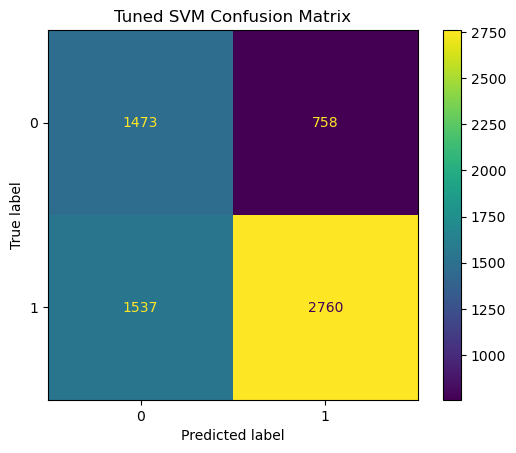

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_men, y_pred_best)

# Print raw values
print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Tuned SVM Confusion Matrix")
plt.show()

## separate approach

linear kernel

In [31]:
# set seed for reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# create SVM pipeline. avoid data leakage
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', kernel='linear', random_state=SEED))
])

# use standard 5 fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,   # randomly shuffle observations before creating folds
    random_state=SEED
)

# cross validated predictions
y_pred = cross_val_predict(
    svm_model,
    X_men,
    y_men,
    cv=cv
)

# print results
accuracy = accuracy_score(y_men, y_pred)
precision = precision_score(y_men, y_pred)
recall = recall_score(y_men, y_pred)
f1 = f1_score(y_men, y_pred)

print("SVM Benchmark (5-Fold CV)\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

SVM Benchmark (5-Fold CV)

Accuracy : 0.6533
Precision: 0.7943
Recall   : 0.6388
F1 Score : 0.7081


In [32]:
# hyperparameter tuning using GridSearch

from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['linear'],
    'svm__class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC())
    ]),
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

grid.fit(X_men, y_men)

print("BEST PARAMETERS:")
print(grid.best_params_)
print("\nBEST CV F1 SCORE:", grid.best_score_)

BEST PARAMETERS:
{'svm__C': 100, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

BEST CV F1 SCORE: 0.7089349922999405


In [33]:
best_model = grid.best_estimator_

y_pred_best = cross_val_predict(
    best_model,
    X_men,
    y_men,
    cv=cv
)

print("TUNED SVM (5-Fold CV)\n")
print("Accuracy :", accuracy_score(y_men, y_pred_best))
print("Precision:", precision_score(y_men, y_pred_best))
print("Recall   :", recall_score(y_men, y_pred_best))
print("F1 Score :", f1_score(y_men, y_pred_best))

TUNED SVM (5-Fold CV)

Accuracy : 0.6541053921568627
Precision: 0.7945680439179428
Recall   : 0.6399813823597859
F1 Score : 0.7089456045372519


Confusion Matrix:
[[1520  711]
 [1547 2750]]


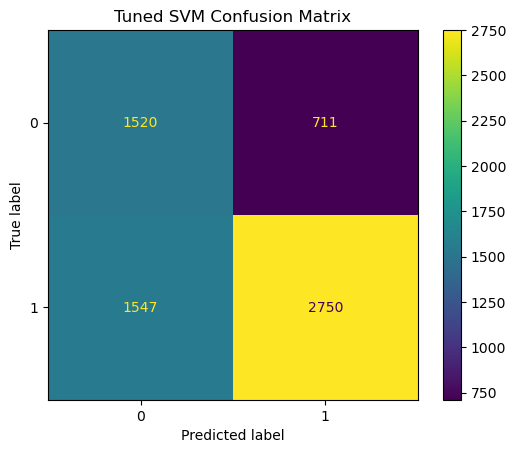

In [34]:
# Compute confusion matrix
cm = confusion_matrix(y_men, y_pred_best)

# Print raw values
print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Tuned SVM Confusion Matrix")
plt.show()

## Another Approach

polynomial kernel

In [35]:
# set seed for reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# create SVM pipeline. avoid data leakage
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', kernel='poly', random_state=SEED))
])

# use standard 5 fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,   # randomly shuffle observations before creating folds
    random_state=SEED
)

# cross validated predictions
y_pred = cross_val_predict(
    svm_model,
    X_men,
    y_men,
    cv=cv
)

# print results
accuracy = accuracy_score(y_men, y_pred)
precision = precision_score(y_men, y_pred)
recall = recall_score(y_men, y_pred)
f1 = f1_score(y_men, y_pred)

print("SVM Benchmark (5-Fold CV)\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

SVM Benchmark (5-Fold CV)

Accuracy : 0.6397
Precision: 0.7722
Recall   : 0.6421
F1 Score : 0.7011


In [36]:
# hyperparameter tuning using GridSearch

from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['poly'],
    'svm__class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC())
    ]),
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

grid.fit(X_men, y_men)

print("BEST PARAMETERS:")
print(grid.best_params_)
print("\nBEST CV F1 SCORE:", grid.best_score_)

BEST PARAMETERS:
{'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'poly'}

BEST CV F1 SCORE: 0.7060600753887554


In [37]:
best_model = grid.best_estimator_

y_pred_best = cross_val_predict(
    best_model,
    X_men,
    y_men,
    cv=cv
)

print("TUNED SVM (5-Fold CV)\n")
print("Accuracy :", accuracy_score(y_men, y_pred_best))
print("Precision:", precision_score(y_men, y_pred_best))
print("Recall   :", recall_score(y_men, y_pred_best))
print("F1 Score :", f1_score(y_men, y_pred_best))

TUNED SVM (5-Fold CV)

Accuracy : 0.6351102941176471
Precision: 0.7515103756238508
Recall   : 0.6658133581568536
F1 Score : 0.706071076011846


Confusion Matrix:
[[1285  946]
 [1436 2861]]


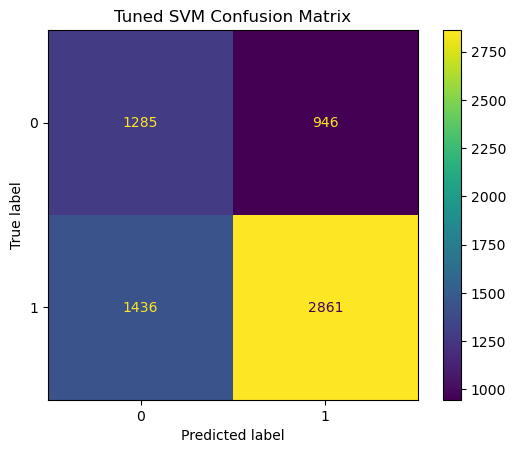

In [38]:
# Compute confusion matrix
cm = confusion_matrix(y_men, y_pred_best)

# Print raw values
print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Tuned SVM Confusion Matrix")
plt.show()

# Fighter Score

In [39]:
def exponential_recent_form(history, decay=0.75, recent_n=5):
    if not history:
        return 0.5

    recent_history = history[-recent_n:]

    outcomes = np.array(
        [fight["win"] for fight in recent_history],
        dtype=float
    )

    # Oldest fight gets the smallest weight,
    # newest fight gets weight 1
    ages = np.arange(len(outcomes) - 1, -1, -1)
    weights = decay ** ages

    return np.average(outcomes, weights=weights)

In [40]:
def calculate_simple_score(history, recent_n=5, decay=0.75):
    if len(history) == 0:
        return 50.0

    total_fights = len(history)
    total_wins = sum(fight["win"] for fight in history)

    career_win_rate = total_wins / total_fights

    recent_form = exponential_recent_form(
        history,
        decay=decay,
        recent_n=recent_n
    )

    finishes = sum(
        fight["win"] and fight["finish"]
        for fight in history
    )

    finish_rate = finishes / max(total_wins, 1)

    streak = 0

    for fight in reversed(history):
        if fight["win"]:
            if streak < 0:
                break
            streak += 1
        else:
            if streak > 0:
                break
            streak -= 1

    streak = np.clip(streak, -3, 3)

    experience_score = np.log1p(total_fights)

    score = (
        30 * career_win_rate
        + 30 * recent_form
        + 5 * streak
        + 10 * finish_rate
        + 5 * experience_score
    )

    return score

Sort fights chronologically and create the fighter histories

In [41]:
from collections import defaultdict

# Make sure event_date is datetime
mdf["event_date"] = pd.to_datetime(mdf["event_date"])

# Sort chronologically
mdf = mdf.sort_values("event_date").reset_index(drop=True)

# Dictionary that will store each fighter's PRIOR fight history
fighter_history = defaultdict(list)

r_scores = []
b_scores = []

for _, row in mdf.iterrows():

    red = row["r_fighter"]
    blue = row["b_fighter"]

    # IMPORTANT:
    # Calculate fighter scores BEFORE adding current fight result
    red_score = calculate_simple_score(fighter_history[red])
    blue_score = calculate_simple_score(fighter_history[blue])

    r_scores.append(red_score)
    b_scores.append(blue_score)

    # Determine outcome
    red_won = row["winner"] == "Red"
    blue_won = row["winner"] == "Blue"

    # Determine whether fight ended in a finish
    method = str(row["method"]).lower()

    finish = (
        "ko" in method
        or "tko" in method
        or "submission" in method
        or "sub" in method
    )

    # Add CURRENT fight to history only AFTER scores were calculated
    fighter_history[red].append({
        "win": int(red_won),
        "finish": int(finish and red_won)
    })

    fighter_history[blue].append({
        "win": int(blue_won),
        "finish": int(finish and blue_won)
    })


# Add scores back to dataset
mdf["r_fighter_score"] = r_scores
mdf["b_fighter_score"] = b_scores

# Difference is what we'll mainly give the model
mdf["fighter_score_diff"] = (
    mdf["r_fighter_score"]
    - mdf["b_fighter_score"]
)

Example: Jon Jones

In [44]:
fighter = "Jon Jones"

mdf[
    (mdf["r_fighter"] == fighter) |
    (mdf["b_fighter"] == fighter)
][
    [
        "event_date",
        "r_fighter",
        "b_fighter",
        "winner",
        "r_fighter_score",
        "b_fighter_score"
    ]
]

,event_date,r_fighter,b_fighter,winner,r_fighter_score,b_fighter_score
954,2008-08-09,Jon Jones,Andre Gusmao,Red,50.000000,50.000000
1047,2009-01-31,Jon Jones,Stephan Bonnar,Red,68.465736,66.056225
1149,2009-07-11,Jon Jones,Jake O'Brien,Red,75.493061,54.323021
1231,2009-12-05,Matt Hamill,Jon Jones,Red,73.176691,85.264805
1290,2010-03-21,Brandon Vera,Jon Jones,Blue,49.676225,47.909094
1387,2010-08-01,Jon Jones,Vladimir Matyushenko,Red,65.583637,68.294409
1522,2011-02-05,Jon Jones,Ryan Bader,Red,75.198181,87.958797
1553,2011-03-19,Mauricio Rua,Jon Jones,Blue,61.472242,83.629633
1690,2011-09-24,Jon Jones,Quinton Jackson,Red,86.267584,73.600603
1773,2011-12-10,Jon Jones,Lyoto Machida,Red,90.679592,63.507902


Updating df_balanced

In [45]:
df_balanced = mdf.copy()

Updating pre fight features

In [46]:
pre_fight_features = [
    "weight_class",
    "age_diff",
    "height_diff",
    "weight_diff",
    "reach_diff",
    "wins_total_diff",
    "losses_total_diff",
    "fighter_score_diff",
    "r_stance",
    "b_stance"
]

Rerun the rest of your existing preprocessing:

In [47]:
X_men = df_balanced[pre_fight_features].copy()
y_men = df_balanced["winner"]

X_men = pd.get_dummies(
    X_men,
    columns=["weight_class", "r_stance", "b_stance"],
    drop_first=True
)

X_men.columns = [
    col.replace("weight_class_", "")
    for col in X_men.columns
]

X_men = X_men.fillna(X_men.mean())

le = LabelEncoder()
y_men = le.fit_transform(y_men)

Running SVM with fighter score included

In [48]:
import random

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            class_weight="balanced",
            kernel="rbf",
            random_state=SEED
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

y_pred = cross_val_predict(
    svm_model,
    X_men,
    y_men,
    cv=cv
)

accuracy = accuracy_score(y_men, y_pred)
precision = precision_score(y_men, y_pred)
recall = recall_score(y_men, y_pred)
f1 = f1_score(y_men, y_pred)

print("SVM + Fighter Score (5-Fold CV)\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

SVM + Fighter Score (5-Fold CV)

Accuracy : 0.6600
Precision: 0.8037
Recall   : 0.6456
F1 Score : 0.7160
